In [1]:
import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset
from matplotlib import cm
import xarray as xr
import pandas as pd
import datetime
#import warnings # Silence the warnings from SHARPpy
#warnings.filterwarnings("ignore")
from scipy import interpolate
from scipy.ndimage import gaussian_filter
import scipy
import scipy.stats
import math
import cmweather
import matplotlib.patches as mpatches
import glob
import os
from metpy.units import units
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 20
from matplotlib.ticker import FormatStrFormatter
import shapely
import shapely.plotting
import shapely.wkt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import metpy.calc as mpcalc
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

from matplotlib.ticker import ScalarFormatter, MultipleLocator
from matplotlib.collections import LineCollection
import matplotlib.transforms as transforms
from metpy.plots import add_metpy_logo, Hodograph, SkewT
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import sharppy
import sharppy.sharptab.profile as profile
import sharppy.sharptab.interp as interp
import sharppy.sharptab.winds as winds
import sharppy.sharptab.utils as utils
import sharppy.sharptab.params as params
import sharppy.sharptab.thermo as thermo


In [2]:
dss_dsh = xr.open_mfdataset('/data/keeling/a/melinda3/NASA/cm1_radiation/temp_cm1_dir/hodo_test_8_33_1m_dss_full/cm1out_0*')
hss_dsh =  xr.open_mfdataset('/data/keeling/a/melinda3/NASA/cm1_radiation/temp_cm1_dir/hodo_test_10_35_1m_dss_full/cm1out_0*')
lss_dsh =  xr.open_mfdataset('/data/keeling/a/melinda3/NASA/cm1_radiation/temp_cm1_dir/hodo_test_6_29_1m_dss_full/cm1out_0*')

In [3]:
theta = dss_dsh.th[0,:,0,0].values*units.kelvin
qv = dss_dsh.qv[0,:,0,0].values*units.kg/units.kg
prs = dss_dsh.prs[0,:,0,0].values*units.pascal
hgt = dss_dsh.zh.values*500*units.meters
uint = dss_dsh.uinterp[0,:,0,0].values*units.meter_per_second
vint = dss_dsh.vinterp[0,:,0,0].values*units.meter_per_second

prs_hpa = prs.to(units.hectopascal)
temp = mpcalc.temperature_from_potential_temperature(prs, theta)
tempc = temp.magnitude-273.15
tempc = tempc*units.degC
sh = mpcalc.specific_humidity_from_mixing_ratio(qv)
dewp = mpcalc.dewpoint_from_specific_humidity(prs, tempc, sh)
dewp = dewp
#dewp[0:119] = dewp[0:119] - 2
u_kts = uint.to(units.knot)
v_kts = vint.to(units.knot)
wnddir = mpcalc.wind_direction(u_kts, v_kts)
wndspd = mpcalc.wind_speed(u_kts, v_kts)

#Calculate 0-6 bulk shear
u_bshear, v_bshear = mpcalc.bulk_shear(prs_hpa, uint, vint, depth = 6 *units.kilometer)
bshear = mpcalc.wind_speed(u_bshear, v_bshear)
pos_srh, neg_srh, total_srh03 = mpcalc.storm_relative_helicity(hgt, uint+17*units.meter_per_second, vint-7*units.meter_per_second,\
                                                                depth = 3 *units.kilometer)

print(bshear, total_srh03)


#prof1 = profile.create_profile(profile='default', pres=prs_hpa, hght=hgt, tmpc=tempc, \
          #                          dwpc=dewp, wspd = wndspd_kts.magnitude, wdir = wnddir.magnitude, missing=-9999, strictQC=False)

theta_hi = hss_dsh.th[0,:,0,0].values*units.kelvin
qv_hi = hss_dsh.qv[0,:,0,0].values*units.kg/units.kg
prs_hi = hss_dsh.prs[0,:,0,0].values*units.pascal
hgt_hi = hss_dsh.zh.values*500*units.meters
uint_hi = hss_dsh.uinterp[0,:,0,0].values*units.meter_per_second
vint_hi = hss_dsh.vinterp[0,:,0,0].values*units.meter_per_second

prs_hpa_hi = prs_hi.to(units.hectopascal)
temp_hi = mpcalc.temperature_from_potential_temperature(prs_hpa_hi, theta_hi)
tempc_hi = temp_hi.magnitude-273.15
tempc_hi = tempc_hi*units.degC
sh_hi = mpcalc.specific_humidity_from_mixing_ratio(qv_hi)
dewp_hi = mpcalc.dewpoint_from_specific_humidity(prs_hi, tempc_hi, sh_hi)
dewp_hi = dewp_hi
#dewp[0:119] = dewp[0:119] - 2
u_kts_hi = uint_hi.to(units.knot)
v_kts_hi = vint_hi.to(units.knot)
wnddir_hi = mpcalc.wind_direction(u_kts_hi, v_kts_hi)
wndspd_hi = mpcalc.wind_speed(u_kts_hi, v_kts_hi)

u_bshear, v_bshear = mpcalc.bulk_shear(prs_hpa_hi, uint_hi, vint_hi, depth = 6 *units.kilometer)
bshear = mpcalc.wind_speed(u_bshear, v_bshear)
pos_srh, neg_srh, total_srh03_hi = mpcalc.storm_relative_helicity(hgt_hi, uint_hi+17*units.meter_per_second, vint_hi-7*units.meter_per_second,\
                                                                depth = 3 *units.kilometer)

print(bshear, total_srh03_hi)


#prof1 = profile.create_profile(profile='default', pres=prs_hpa, hght=hgt, tmpc=tempc, \
          #                          dwpc=dewp, wspd = wndspd_kts.magnitude, wdir = wnddir.magnitude, missing=-9999, strictQC=False)

theta_lo = lss_dsh.th[0,:,0,0].values*units.kelvin
qv_lo = lss_dsh.qv[0,:,0,0].values*units.kg/units.kg
prs_lo = lss_dsh.prs[0,:,0,0].values*units.pascal
hgt_lo = lss_dsh.zh.values*500*units.meters
uint_lo = lss_dsh.uinterp[0,:,0,0].values*units.meter_per_second
vint_lo = lss_dsh.vinterp[0,:,0,0].values*units.meter_per_second

prs_hpa_lo = prs_lo.to(units.hectopascal)
temp_lo = mpcalc.temperature_from_potential_temperature(prs_hpa_lo, theta_lo)
tempc_lo = temp_lo.magnitude-273.15
tempc_lo = tempc_lo*units.degC
sh_lo = mpcalc.specific_humidity_from_mixing_ratio(qv_lo)
dewp_lo = mpcalc.dewpoint_from_specific_humidity(prs_lo, tempc_lo, sh_lo)
dewp_lo = dewp_lo
#dewp[0:119] = dewp[0:119] - 2
u_kts_lo = uint_lo.to(units.knot)
v_kts_lo = vint_lo.to(units.knot)
wnddir_lo = mpcalc.wind_direction(u_kts_lo, v_kts_lo)
wndspd_lo = mpcalc.wind_speed(u_kts_lo, v_kts_lo)

u_bshear, v_bshear = mpcalc.bulk_shear(prs_hpa_lo, uint_lo, vint_lo, depth = 6 *units.kilometer)
bshear = mpcalc.wind_speed(u_bshear, v_bshear)
pos_srh, neg_srh, total_srh03_lo = mpcalc.storm_relative_helicity(hgt_lo, uint_lo+17*units.meter_per_second, vint_lo-7*units.meter_per_second,\
                                                                depth = 3 *units.kilometer)

print(bshear, total_srh03_lo)


#prof1 = profile.create_profile(profile='default', pres=prs_hpa, hght=hgt, tmpc=tempc, \
          #                          dwpc=dewp, wspd = wndspd_kts.magnitude, wdir = wnddir.magnitude, missing=-9999, strictQC=False)


33.7420768737793 meter_per_second 235.91656384289217 meter ** 2 / second ** 2
36.09693908691406 meter_per_second 306.1290419813258 meter ** 2 / second ** 2
29.472253799438477 meter_per_second 158.19922702440908 meter ** 2 / second ** 2


In [4]:
#Calculate the Bunkers Motion for each of the supercell/shear cases

rm_dsh, lm_dsh, mean_dsh = mpcalc.bunkers_storm_motion(prs_hpa, uint, vint, hgt)
critang_dsh = mpcalc.critical_angle(prs_hpa, uint, vint, hgt, rm_dsh[0], rm_dsh[1])

rm_lsh, lm_lsh, mean_lsh = mpcalc.bunkers_storm_motion(prs_hpa_lo, uint_lo, vint_lo, hgt)
critang_lsh = mpcalc.critical_angle(prs_hpa_lo, uint_lo, vint_lo, hgt, rm_lsh[0], rm_lsh[0])

rm_hsh, lm_hsh, mean_hsh = mpcalc.bunkers_storm_motion(prs_hpa_hi, uint_hi, vint_hi, hgt)
critang_hsh = mpcalc.critical_angle(prs_hpa_hi, uint_hi, vint_hi, hgt, rm_hsh[0], rm_hsh[0])

print(rm_dsh, critang_dsh)
print(rm_lsh, critang_lsh)
print(rm_hsh, critang_hsh)

[-0.29586637020111084 6.692411422729492] meter_per_second 76.87297013919215 degree
[-2.151768207550049 4.8813557624816895] meter_per_second 106.4395442288743 degree
[1.525989055633545 8.505867004394531] meter_per_second 92.3789672558084 degree


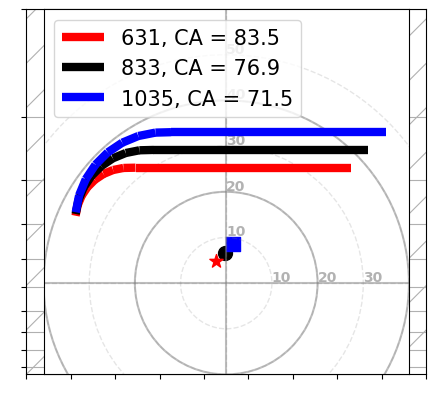

In [ ]:
# Create a new figure. The dimensions here give a good aspect ratio

fig = plt.figure(figsize=(8,8))
skew = SkewT(fig, rotation=45, rect=(0.05, 0.05, 0.50, 0.90))

ax = inset_axes(skew.ax, '100%', '100%', loc = 'center')
h = Hodograph(ax, component_range=40.)
skew.ax.set_yticklabels([])
skew.ax.set_xticklabels([])

# Add two separate grid increments for a cooler look. This also
# helps to increase readability
h.add_grid(increment=20, ls='-', lw=1.5, alpha=0.5)
h.add_grid(increment=10, ls='--', lw=1, alpha=0.2)

# The next few steps makes for a clean hodograph inset, removing the
# tick marks, tick labels, and axis labels
h.ax.set_box_aspect(1)
h.ax.set_yticklabels([])
h.ax.set_xticklabels([])
h.ax.set_xticks([])
h.ax.set_yticks([])
h.ax.set_xlabel(' ')
h.ax.set_ylabel(' ')

# Here we can add a simple Python for loop that adds tick marks
# to the inside of the hodograph plot to increase readability!
plt.xticks(np.arange(0, 0, 1))
plt.yticks(np.arange(0, 0, 1))
for i in range(10, 60, 10):
    h.ax.annotate(str(i), (i, 0), xytext=(0, 2), textcoords='offset pixels',
                  clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)
for i in range(10, 120, 10):
    h.ax.annotate(str(i), (0, i), xytext=(0, 2), textcoords='offset pixels',
                  clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)

# plot the hodograph itself, using plot_colormapped, colored
# by height
ubshr6, vbshr6 = mpcalc.bulk_shear(prs_hpa, u_kts, v_kts, height=hgt, depth=6 * units.km)
bshear6 = mpcalc.wind_speed(ubshr6, vbshr6)
ubshr62, vbshr62 = mpcalc.bulk_shear(prs_hpa_hi, u_kts_hi, v_kts_hi, height=hgt_hi, depth=6 * units.km)
bshear62 = mpcalc.wind_speed(ubshr62, vbshr62)
ubshr63, vbshr63 = mpcalc.bulk_shear(prs_hpa_lo, u_kts_lo, v_kts_lo, height=hgt_hi, depth=6 * units.km)
bshear63 = mpcalc.wind_speed(ubshr63, vbshr63)
h.plot_colormapped(u_kts_lo, v_kts_lo, c=hgt_lo, linewidth=6, label='629, CA = 83.5', color = 'red')
h.plot_colormapped(u_kts, v_kts, c=hgt, linewidth=6, label='833, CA = 76.9', color = 'black')
h.plot_colormapped(u_kts_hi, v_kts_hi, c=hgt_hi, linewidth= 6, label='1035, CA = 71.5', color = 'blue')
#h.plot_colormapped(u_kts_lo, v_kts_lo, c=hgt_lo, linewidth=6, label='629, CA = 83.5', color = 'red')
h.ax.set_ylim(0., 40.)
h.ax.legend(loc = 'upper left', fontsize = 15)
# compute Bunkers storm motion so we can plot it on the hodograph!
h.ax.scatter(rm_dsh[0], rm_dsh[1], marker = 'o', color = 'black', s = 100, label = 'DSH RM, CA = %0.2f'%critang_dsh)
h.ax.scatter(rm_lsh[0], rm_lsh[1], marker = '*', color = 'red', s = 100, label = 'LSH RM')
h.ax.scatter(rm_hsh[0], rm_hsh[1], marker = 's', color = 'blue', s = 100, label = 'HSH RM')


#print(bshear6)
#print(bshear62)"""

In [4]:
#Load the OT/UCA data
ot_629 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_6_29_1m_dss_full.csv')
ot_633 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_6_33_1m_dss_full.csv')
ot_635 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_6_35_1m_dss_full.csv')

ot_829 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_8_29_1m_dss_full.csv')
ot_833 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_8_33_1m_dss_full.csv')
ot_835 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_8_35_1m_dss_full.csv')

ot_1029 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_10_29_1m_dss_full.csv')
ot_1033 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_10_33_1m_dss_full.csv')
ot_1035 = pd.read_csv('/data/keeling/a/melinda3/gpm/data_dir/final_tracking_algo_hodo_test_10_35_1m_dss_full.csv')


In [5]:
#Load the OT/UCA data
d = {}
d_full = {}
d_full2 = {}
d2 = {}

path = '/data/keeling/a/melinda3/gpm/data_dir/'

lower_shear = [6, 8, 10]
upper_shear = [29, 29, 33, 35]

for li in lower_shear:
    for ui in upper_shear:
        if (li == 10) & (ui == 29):
            continue
        else:
            hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
            file_in = pd.read_csv(path+hash)
            file_in = file_in.replace(-9999, np.nan)
            d_full["area{0}_{1}_dss".format(li, ui)] = file_in


d2 = d_full


In [6]:
#Break the output into layers, group it by time to get the average loction of the updraft and the plot it for the full tracking period (broken into pre and post-split)
ot_629_low = ot_629[(ot_629.z >= 2.5) & (ot_629.z < 4)]
ot_629_mid = ot_629[(ot_629.z >= 4) & (ot_629.z < 8)]
ot_629_high = ot_629[(ot_629.z >= 8) & (ot_629.z < 12.5)]

ot_633_low = ot_633[(ot_633.z >= 2.5) & (ot_633.z < 4)]
ot_633_mid = ot_633[(ot_633.z >= 4) & (ot_633.z < 8)] 
ot_633_high = ot_633[(ot_633.z >= 8) & (ot_633.z < 12.5)]

ot_635_low = ot_635[(ot_635.z >= 2.5) & (ot_635.z < 4)]
ot_635_mid = ot_635[(ot_635.z >= 4) & (ot_635.z < 8)]
ot_635_high = ot_635[(ot_635.z >= 8) & (ot_635.z < 12.5)]

ot_629_low_grouped = ot_629_low.groupby('time')
ot_629_mid_grouped = ot_629_mid.groupby('time')
ot_629_high_grouped = ot_629_high.groupby('time')
ot_633_low_grouped = ot_633_low.groupby('time')
ot_633_mid_grouped = ot_633_mid.groupby('time')
ot_633_high_grouped = ot_633_high.groupby('time')
ot_635_low_grouped = ot_635_low.groupby('time')
ot_635_mid_grouped = ot_635_mid.groupby('time')
ot_635_high_grouped = ot_635_high.groupby('time')

#Break the output into layers, group it by time to get the average loction of the updraft and the plot it for the full tracking period (broken into pre and post-split)
ot_829_low = ot_829[(ot_829.z >= 2.5) & (ot_829.z < 4)]
ot_829_mid = ot_829[(ot_829.z >= 4) & (ot_829.z < 8)]
ot_829_high = ot_829[(ot_829.z >= 8) & (ot_829.z < 12.5)]

ot_833_low = ot_833[(ot_833.z >= 2.5) & (ot_833.z < 4)]
ot_833_mid = ot_833[(ot_833.z >= 4) & (ot_833.z < 8)] 
ot_833_high = ot_833[(ot_833.z >= 8) & (ot_833.z < 12.5)]

ot_835_low = ot_835[(ot_835.z >= 2.5) & (ot_835.z < 4)]
ot_835_mid = ot_835[(ot_835.z >= 4) & (ot_835.z < 8)]
ot_835_high = ot_835[(ot_835.z >= 8) & (ot_835.z < 12.5)]

ot_829_low_grouped = ot_829_low.groupby('time')
ot_829_mid_grouped = ot_829_mid.groupby('time')
ot_829_high_grouped = ot_829_high.groupby('time')
ot_833_low_grouped = ot_833_low.groupby('time')
ot_833_mid_grouped = ot_833_mid.groupby('time')
ot_833_high_grouped = ot_833_high.groupby('time')
ot_835_low_grouped = ot_835_low.groupby('time')
ot_835_mid_grouped = ot_835_mid.groupby('time')
ot_835_high_grouped = ot_835_high.groupby('time')

#Break the output into layers, group it by time to get the average loction of the updraft and the plot it for the full tracking period (broken into pre and post-split)
ot_1029_low = ot_1029[(ot_1029.z >= 2.5) & (ot_1029.z < 4)]
ot_1029_mid = ot_1029[(ot_1029.z >= 4) & (ot_1029.z < 8)]
ot_1029_high = ot_1029[(ot_1029.z >= 8) & (ot_1029.z < 12.5)]

ot_1033_low = ot_1033[(ot_1033.z >= 2.5) & (ot_1033.z < 4)]
ot_1033_mid = ot_1033[(ot_1033.z >= 4) & (ot_1033.z < 8)] 
ot_1033_high = ot_1033[(ot_1033.z >= 8) & (ot_1033.z < 12.5)]

ot_1035_low = ot_1035[(ot_1035.z >= 2.5) & (ot_1035.z < 4)]
ot_1035_mid = ot_1035[(ot_1035.z >= 4) & (ot_1035.z < 8)]
ot_1035_high = ot_1035[(ot_1035.z >= 8) & (ot_1035.z < 12.5)]

ot_1029_low_grouped = ot_1029_low.groupby('time')
ot_1029_mid_grouped = ot_1029_mid.groupby('time')
ot_1029_high_grouped = ot_1029_high.groupby('time')
ot_1033_low_grouped = ot_1033_low.groupby('time')
ot_1033_mid_grouped = ot_1033_mid.groupby('time')
ot_1033_high_grouped = ot_1033_high.groupby('time')
ot_1035_low_grouped = ot_1035_low.groupby('time')
ot_1035_mid_grouped = ot_1035_mid.groupby('time')
ot_1035_high_grouped = ot_1035_high.groupby('time')

In [7]:
#Get the median x and y position and break it up by pre and post-split
lsh_mid_locs_x629 = ot_629_mid_grouped['centroid-0'].median()
lsh_mid_locs_y629 = ot_629_mid_grouped['centroid-1'].median()
lsh_mid_prex_629 = lsh_mid_locs_x629[lsh_mid_locs_x629.index <= ot_629['time_split'].iloc[0]]
lsh_mid_prey_629 = lsh_mid_locs_y629[lsh_mid_locs_y629.index <= ot_629['time_split'].iloc[0]]
lsh_mid_postx_629 = lsh_mid_locs_x629[lsh_mid_locs_x629.index >= ot_629['time_split'].iloc[0]]
lsh_mid_posty_629 = lsh_mid_locs_y629[lsh_mid_locs_y629.index >= ot_629['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
dsh_mid_locs_x633 = ot_633_mid_grouped['centroid-0'].median()
dsh_mid_locs_y633 = ot_633_mid_grouped['centroid-1'].median()
dsh_mid_prex_633 = dsh_mid_locs_x633[dsh_mid_locs_x633.index <= ot_633['time_split'].iloc[0]]
dsh_mid_prey_633 = dsh_mid_locs_y633[dsh_mid_locs_y633.index <= ot_633['time_split'].iloc[0]]
dsh_mid_postx_633 = dsh_mid_locs_x633[dsh_mid_locs_x633.index >= ot_633['time_split'].iloc[0]]
dsh_mid_posty_633 = dsh_mid_locs_y633[dsh_mid_locs_y633.index >= ot_633['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
hsh_mid_locs_x635 = ot_635_mid_grouped['centroid-0'].median()
hsh_mid_locs_y635 = ot_635_mid_grouped['centroid-1'].median()
hsh_mid_prex_635 = hsh_mid_locs_x635[hsh_mid_locs_x635.index <= ot_635['time_split'].iloc[0]]
hsh_mid_prey_635 = hsh_mid_locs_y635[hsh_mid_locs_y635.index <= ot_635['time_split'].iloc[0]]
hsh_mid_postx_635 = hsh_mid_locs_x635[hsh_mid_locs_x635.index >= ot_635['time_split'].iloc[0]]
hsh_mid_posty_635 = hsh_mid_locs_y635[hsh_mid_locs_y635.index >= ot_635['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
lsh_mid_locs_x829 = ot_829_mid_grouped['centroid-0'].median()
lsh_mid_locs_y829 = ot_829_mid_grouped['centroid-1'].median()
lsh_mid_prex_829 = lsh_mid_locs_x829[lsh_mid_locs_x829.index <= ot_829['time_split'].iloc[0]]
lsh_mid_prey_829 = lsh_mid_locs_y829[lsh_mid_locs_y829.index <= ot_829['time_split'].iloc[0]]
lsh_mid_postx_829 = lsh_mid_locs_x829[lsh_mid_locs_x829.index >= ot_829['time_split'].iloc[0]]
lsh_mid_posty_829 = lsh_mid_locs_y829[lsh_mid_locs_y829.index >= ot_829['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
dsh_mid_locs_x833 = ot_833_mid_grouped['centroid-0'].median()
dsh_mid_locs_y833 = ot_833_mid_grouped['centroid-1'].median()
dsh_mid_prex_833 = dsh_mid_locs_x833[dsh_mid_locs_x833.index <= ot_833['time_split'].iloc[0]]
dsh_mid_prey_833 = dsh_mid_locs_y833[dsh_mid_locs_y833.index <= ot_833['time_split'].iloc[0]]
dsh_mid_postx_833 = dsh_mid_locs_x833[dsh_mid_locs_x833.index >= ot_833['time_split'].iloc[0]]
dsh_mid_posty_833 = dsh_mid_locs_y833[dsh_mid_locs_y833.index >= ot_833['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
hsh_mid_locs_x835 = ot_835_mid_grouped['centroid-0'].median()
hsh_mid_locs_y835 = ot_835_mid_grouped['centroid-1'].median()
hsh_mid_prex_835 = hsh_mid_locs_x835[hsh_mid_locs_x835.index <= ot_835['time_split'].iloc[0]]
hsh_mid_prey_835 = hsh_mid_locs_y835[hsh_mid_locs_y835.index <= ot_835['time_split'].iloc[0]]
hsh_mid_postx_835 = hsh_mid_locs_x835[hsh_mid_locs_x835.index >= ot_835['time_split'].iloc[0]]
hsh_mid_posty_835 = hsh_mid_locs_y835[hsh_mid_locs_y835.index >= ot_835['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
lsh_mid_locs_x1029 = ot_1029_mid_grouped['centroid-0'].median()
lsh_mid_locs_y1029 = ot_1029_mid_grouped['centroid-1'].median()
lsh_mid_prex_1029 = lsh_mid_locs_x1029[lsh_mid_locs_x1029.index <= ot_1029['time_split'].iloc[0]]
lsh_mid_prey_1029 = lsh_mid_locs_y1029[lsh_mid_locs_y1029.index <= ot_1029['time_split'].iloc[0]]
lsh_mid_postx_1029 = lsh_mid_locs_x1029[lsh_mid_locs_x1029.index >= ot_1029['time_split'].iloc[0]]
lsh_mid_posty_1029 = lsh_mid_locs_y1029[lsh_mid_locs_y1029.index >= ot_1029['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
dsh_mid_locs_x1033 = ot_1033_mid_grouped['centroid-0'].median()
dsh_mid_locs_y1033 = ot_1033_mid_grouped['centroid-1'].median()
dsh_mid_prex_1033 = dsh_mid_locs_x1033[dsh_mid_locs_x1033.index <= ot_1033['time_split'].iloc[0]]
dsh_mid_prey_1033 = dsh_mid_locs_y1033[dsh_mid_locs_y1033.index <= ot_1033['time_split'].iloc[0]]
dsh_mid_postx_1033 = dsh_mid_locs_x1033[dsh_mid_locs_x1033.index >= ot_1033['time_split'].iloc[0]]
dsh_mid_posty_1033 = dsh_mid_locs_y1033[dsh_mid_locs_y1033.index >= ot_1033['time_split'].iloc[0]]

#Get the median x and y position and break it up by pre and post-split
hsh_mid_locs_x1035 = ot_1035_mid_grouped['centroid-0'].median()
hsh_mid_locs_y1035 = ot_1035_mid_grouped['centroid-1'].median()
hsh_mid_prex_1035 = hsh_mid_locs_x1035[hsh_mid_locs_x1035.index <= ot_1035['time_split'].iloc[0]]
hsh_mid_prey_1035 = hsh_mid_locs_y1035[hsh_mid_locs_y1035.index <= ot_1035['time_split'].iloc[0]]
hsh_mid_postx_1035 = hsh_mid_locs_x1035[hsh_mid_locs_x1035.index >= ot_1035['time_split'].iloc[0]]
hsh_mid_posty_1035 = hsh_mid_locs_y1035[hsh_mid_locs_y1035.index >= ot_1035['time_split'].iloc[0]]

In [8]:
#Let's plot the storm motion on a hodograph to see how the overall storm motion changes across the post-split period
#We should find the difference in the median vertical storm position from the first time post split to 99 mins
first_post_629 = ot_629[ot_629.time == ot_629['time_split'].iloc[0]+ 1]
first_post_633 = ot_633[ot_633.time == ot_633['time_split'].iloc[0] + 1]
first_post_635 = ot_635[ot_635.time == ot_635['time_split'].iloc[0] + 1]

first_post_829 = ot_829[ot_829.time == ot_829['time_split'].iloc[0] + 1]
first_post_833 = ot_833[ot_833.time == ot_833['time_split'].iloc[0] + 1]
first_post_835 = ot_835[ot_835.time ==  ot_835['time_split'].iloc[0] + 1]

first_post_1029 = ot_1029[ot_1029.time == ot_1029['time_split'].iloc[0] + 1]
first_post_1033 = ot_1033[ot_1033.time == ot_1033['time_split'].iloc[0] + 1]
first_post_1035 = ot_1035[ot_1035.time == ot_1035['time_split'].iloc[0] + 1]

last_post_629 = ot_629[ot_629.time == 99]
last_post_633 = ot_633[ot_633.time == 99]
last_post_635 = ot_635[ot_635.time == 99]

last_post_829 = ot_829[ot_829.time == 99]
last_post_833 = ot_833[ot_833.time == 99]
last_post_835 = ot_835[ot_835.time == 99]

last_post_1029 = ot_1029[ot_1029.time == 99]
last_post_1033 = ot_1033[ot_1033.time == 99]
last_post_1035 = ot_1035[ot_1035.time == 99]

In [9]:
median_first_629_0 = first_post_629['centroid-0'].median()
median_first_629_1 = first_post_629['centroid-1'].median()
median_first_633_0 = first_post_633['centroid-0'].median()
median_first_633_1 = first_post_633['centroid-1'].median()
median_first_635_0 = first_post_635['centroid-0'].median()
median_first_635_1 = first_post_635['centroid-1'].median()
median_first_829_0 = first_post_829['centroid-0'].median()
median_first_829_1 = first_post_829['centroid-1'].median()
median_first_833_1 = first_post_833['centroid-1'].median()
median_first_833_0 = first_post_833['centroid-0'].median()
median_first_833_1 = first_post_833['centroid-1'].median()
median_first_835_0 = first_post_835['centroid-0'].median()
median_first_835_1 = first_post_835['centroid-1'].median()
median_first_1029_0 = first_post_1029['centroid-0'].median()
median_first_1029_1 = first_post_1029['centroid-1'].median()
median_first_1033_0 = first_post_1033['centroid-0'].median()
median_first_1033_1 = first_post_1033['centroid-1'].median()
median_first_1035_0 = first_post_1035['centroid-0'].median()
median_first_1035_1 = first_post_1035['centroid-1'].median()

median_last_629_0 = last_post_629['centroid-0'].median()
median_last_629_1 = last_post_629['centroid-1'].median()
median_last_633_0 = last_post_633['centroid-0'].median()
median_last_633_1 = last_post_633['centroid-1'].median()
median_last_635_0 = last_post_635['centroid-0'].median()
median_last_635_1 = last_post_635['centroid-1'].median()
median_last_829_0 = last_post_829['centroid-0'].median()
median_last_829_1 = last_post_829['centroid-1'].median()
median_last_833_0 = last_post_833['centroid-0'].median()
median_last_833_1 = last_post_833['centroid-1'].median()
median_last_835_0 = last_post_835['centroid-0'].median()
median_last_835_1 = last_post_835['centroid-1'].median()
median_last_1029_0 = last_post_1029['centroid-0'].median()
median_last_1029_1 = last_post_1029['centroid-1'].median()
median_last_1033_0 = last_post_1033['centroid-0'].median()
median_last_1033_1 = last_post_1033['centroid-1'].median()
median_last_1035_0 = last_post_1035['centroid-0'].median()
median_last_1035_1 = last_post_1035['centroid-1'].median()

In [10]:
###DO I NEED TO SUBTRACT OUT THE MOTION OF THE DOMAIN FROM THE MOTION OF THE STORM???????
#Let's calculate the Euclidean distance between the two points
dist_629_x = np.sqrt((median_last_629_0 - median_first_629_0)**2)*500
dist_633_x = np.sqrt((median_last_633_0 - median_first_633_0)**2)*500
dist_635_x = np.sqrt((median_last_635_0 - median_first_635_0)**2)*500
dist_829_x = np.sqrt((median_last_829_0 - median_first_829_0)**2)*500
dist_833_x = np.sqrt((median_last_833_0 - median_first_833_0)**2)*500
dist_835_x = np.sqrt((median_last_835_0 - median_first_835_0)**2)*500
dist_1029_x = np.sqrt((median_last_1029_0 - median_first_1029_0)**2)*500
dist_1033_x = np.sqrt((median_last_1033_0 - median_first_1033_0) **2)*500
dist_1035_x = np.sqrt((median_last_1035_0 - median_first_1035_0)**2)*500
dist_629_y = np.sqrt((median_last_629_1 - median_first_629_1)**2)*500
dist_633_y = np.sqrt((median_last_633_1 - median_first_633_1)**2)*500
dist_635_y = np.sqrt((median_last_635_1 - median_first_635_1)**2)*500
dist_829_y = np.sqrt((median_last_829_1 - median_first_829_1)**2)*500
dist_833_y = np.sqrt((median_last_833_1 - median_first_833_1)**2)*500
dist_835_y = np.sqrt((median_last_835_1 - median_first_835_1)**2)*500
dist_1029_y = np.sqrt((median_last_1029_1 - median_first_1029_1)**2)*500
dist_1033_y = np.sqrt((median_last_1033_1 - median_first_1033_1) **2)*500
dist_1035_y = np.sqrt((median_last_1035_1 - median_first_1035_1)**2)*500

#Now let's get the differences in the times to get dt
t_629 = 99 - (ot_629['time_split'].iloc[0]+ 1) 
t_633 = 99 - (ot_633['time_split'].iloc[0]+ 1) 
t_635 = 99  - (ot_635['time_split'].iloc[0]+ 1)
t_829 = 99 - (ot_829['time_split'].iloc[0]+ 1) 
t_833 = 99 - (ot_833['time_split'].iloc[0]+ 1)
t_835 = 99 - (ot_835['time_split'].iloc[0]+ 1)
t_1029 = 99 - (ot_1029['time_split'].iloc[0]+ 1)
t_1033 = 99 - (ot_1033['time_split'].iloc[0]+ 1)
t_1035 = 99 - (ot_1035['time_split'].iloc[0]+ 1)
t_629 = t_629*60
t_633 = t_633*60
t_635 = t_635*60
t_829 = t_829*60
t_833 = t_833*60
t_835 = t_835*60
t_1029 = t_1029*60
t_1033 = t_1033*60
t_1035 = t_1035*60

#Calculate storm motion
sm_629_x = dist_629_x/t_629
sm_629_y = dist_629_y/t_629
sm_633_x = dist_633_x/t_633
sm_633_y = dist_633_y/t_633
sm_635_x = dist_635_x/t_635
sm_635_y = dist_635_y/t_635
sm_829_x = dist_829_x/t_829
sm_829_y = dist_829_y/t_829
sm_833_x = dist_833_x/t_833
sm_833_y = dist_833_y/t_833
sm_835_x = dist_835_x/t_835
sm_835_y = dist_835_y/t_835
sm_1029_x = dist_1029_x/t_1029
sm_1029_y = dist_1029_y/t_1029
sm_1033_x = dist_1033_x/t_1033
sm_1033_y = dist_1033_y/t_1033
sm_1035_x = dist_1035_x/t_1035
sm_1035_y = dist_1035_y/t_1035


Text(0.5, 1.0, 'a) HR6 Storm Motion')

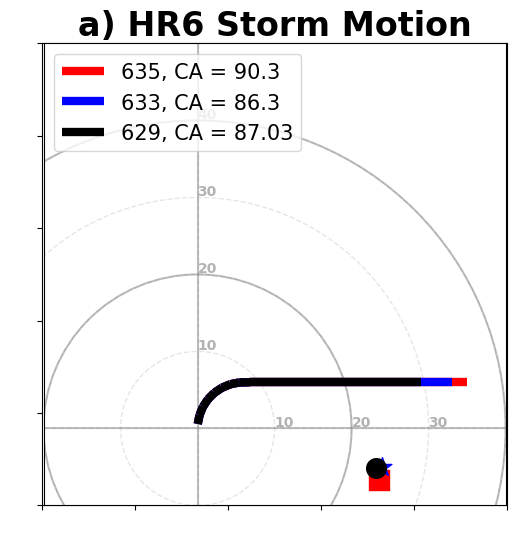

In [12]:
hr = 6
hl = [35, 33, 29]
fig, ax1 = plt.subplots(1, 1, figsize=(6,6))
ax1.set_yticklabels([])
ax1.set_xticklabels([])
ax = inset_axes(ax1, '100%', '100%', loc = 'center')
h = Hodograph(ax, component_range=35.)
# Add two separate grid increments for a cooler look. This also
# helps to increase readability
h.add_grid(increment=20, ls='-', lw=1.5, alpha=0.5)
h.add_grid(increment=10, ls='--', lw=1, alpha=0.2)
ax.set_yticklabels([])
ax.set_xticklabels([])

# The next few steps makes for a clean hodograph inset, removing the
# tick marks, tick labels, and axis labels
h.ax.set_box_aspect(1)
h.ax.set_yticklabels([])
h.ax.set_xticklabels([])
h.ax.set_xticks([])
h.ax.set_yticks([])
h.ax.set_xlabel(' ')
h.ax.set_ylabel(' ')

# Here we can add a simple Python for loop that adds tick marks
# to the inside of the hodograph plot to increase readability!
plt.xticks(np.arange(0, 0, 1))
plt.yticks(np.arange(0, 0, 1))
for i in range(10, 60, 10):
    h.ax.annotate(str(i), (i, 0), xytext=(0, 2), textcoords='offset pixels',
                  clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)
for i in range(10, 120, 10):
    h.ax.annotate(str(i), (0, i), xytext=(0, 2), textcoords='offset pixels',
                  clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)
for leng in hl:
    path_1 = '/data/keeling/a/melinda3/NASA/cm1_radiation/temp_cm1_dir/hodo_test_'
    hash = str(hr)+'_'+str(leng)+'_1m_dss_full/cm1out_000001.nc'
    current_file = xr.open_dataset(path_1 + hash)
    u_curr = current_file['uinterp'][0,:,0,0].values*units.meter_per_second + 17*units.meter_per_second
    v_curr = current_file['vinterp'][0,:,0,0].values*units.meter_per_second - 7*units.meter_per_second
    hgt_curr = current_file['zh'][:].values*units.kilometer
    prs_curr = current_file['prs'][0,:,0,0].values*units.pascal
    #Calculate the critical angle
    if leng == 35:
        sm_x_curr = sm_635_x +17
        sm_y_curr = sm_635_y -7
        rm_b, lm_b, wm = mpcalc.bunkers_storm_motion(prs_curr, u_curr, v_curr, hgt_curr)
        ca_current = mpcalc.critical_angle(prs_curr, u_curr, v_curr, hgt_curr, sm_x_curr*units.meter_per_second, sm_y_curr*units.meter_per_second)
        h.plot_colormapped(u_curr, v_curr, c = hgt_curr, linewidth=6, label=str(hr)+str(leng)+', CA = %0.1f'%ca_current.magnitude,\
                            color = 'red')
        h.ax.scatter(sm_x_curr, sm_y_curr, marker = 's', color = 'red', s = 200)
        #h.ax.text((rm_b[0].m ), (rm_b[1].m ), 'RM', weight='bold', ha='left',
         # fontsize=13, alpha=0.6, color = 'red')
    elif leng == 33:
        sm_x_curr = sm_633_x +17
        sm_y_curr = sm_633_y -7
        ca_current = mpcalc.critical_angle(prs_curr, u_curr, v_curr, hgt_curr,  sm_x_curr*units.meter_per_second, sm_y_curr*units.meter_per_second)
        h.plot_colormapped(u_curr, v_curr, c = hgt_curr, linewidth=6, label=str(hr)+str(leng)+', CA = %0.1f'%ca_current.magnitude,\
                            color = 'blue')
        h.ax.scatter(sm_x_curr, sm_y_curr, marker = '*', color = 'blue', s = 200)
        #rm_b, lm_b, wm = mpcalc.bunkers_storm_motion(prs_curr, u_curr, v_curr, hgt_curr)
        #h.ax.text((rm_b[0].m ), (rm_b[1].m ), 'RM', weight='bold', ha='left',
         # fontsize=13, alpha=0.6, color = 'blue')
    elif leng == 29:
        sm_x_curr = sm_629_x + 17
        sm_y_curr = sm_629_y - 7
        ca_current = mpcalc.critical_angle(prs_curr, u_curr, v_curr, hgt_curr,  sm_x_curr*units.meter_per_second, sm_y_curr*units.meter_per_second)
        h.plot_colormapped(u_curr, v_curr, c= hgt_curr, linewidth=6, label=str(hr)+str(leng)+', CA = %0.2f'%ca_current.magnitude,\
                            color = 'black')
        h.ax.scatter(sm_x_curr, sm_y_curr, marker = 'o', color = 'black', s = 200)
        #rm_b, lm_b, wm = mpcalc.bunkers_storm_motion(prs_curr, u_curr, v_curr, hgt_curr)
        #h.ax.text((rm_b[0].m ), (rm_b[1].m ), 'RM', weight='bold', ha='left',
         # fontsize=13, alpha=0.6, color = 'black')

h.ax.set_ylim(0., 40.)
h.ax.set_xlim(-20., 40.)
h.ax.legend(loc = 'upper left', fontsize = 15)
plt.title('a) HR6 Storm Motion', weight = 'bold')

In [ ]:
t1 = mpcalc.critical_angle(prs_curr, u_curr, v_curr, hgt_curr,  sm_629_x*units.meter_per_second, sm_629_y*units.meter_per_second)

In [ ]:
pos_srh, neg_srh, total_srh03_lo = mpcalc.storm_relative_helicity(hgt_lo, uint_lo+17*units.meter_per_second, vint_lo-7*units.meter_per_second,\
                                                                depth = 3 *units.kilometer)

In [52]:
label

'631, CA = 84.8'

In [49]:
ca_current

84.78290285764709 <Unit('degree')>